In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import os
import sys
from pathlib import Path
from importlib import reload

Since this notebook is in a directory below the main one, we have to add the parent path to sys.path and then import it

In [2]:
module_path = Path('..').resolve()
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))
import prospector_mcmc as pm_lib

Read the filters and catalog.  
Remember to change the paths to each of them!  
prospector_mcmc itself imports custom_prospector_tools, so any function you need from that script is also available via `pm_lib.cpt`.

In [24]:
filter_list = '/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/FILTER/SPHEREx_306/fiducial_filters.txt'
filename = '../data/hotdog_l4_specz_collate_gals.parq'

filters, lamb_obs = pm_lib.cpt.read_filters(filter_list, return_lamb_obs=True)
cat = pm_lib.catalog(filename)

sid = 1663027938116763658   # pick one for example
idx = np.where(cat.spherex_ids == sid)[0][0]
zspec = cat.zspecs[idx]
zphot = cat.zphots[idx]
zphot_u68 = cat.zphots_u68[idx]
zphot_l68 = cat.zphots_l68[idx]
zphot_std = cat.zphots_std[idx]
zsig = (zphot_u68-zphot_l68)/2
spec = cat.spectra[idx]
err = cat.error[idx]
frac102 = cat.frac102[idx]
nonzeros = err != 50000.0
external_phots = cat.get_external_phots(SPHERExRefID=sid)

In [5]:
cat.dat

,SPHERExRefID,spherex_class,ra,dec,LS_z_mag_spherex_nat,WISE_W1_mag_spherex_nat,WISE_W2_mag_spherex_nat,LS_z_spherex_nat,WISE_W1_spherex_nat,WISE_W2_spherex_nat,...,2MASS_Ks_error,WISE_W1,WISE_W2,WISE_W1_error,WISE_W2_error,WISE_W3,WISE_W4,WISE_W3_error,WISE_W4_error,z_specz
0,1838385083292057605,32,4.198132,-3.614465,19.196869,18.602290,NaN,76.081457,131.555883,NaN,...,-9999.000000,83.868717,74.267704,2.780178,4.445120,367.451479,2318.462095,161.056081,-9999.000000,0.283411
1,1838385091445784579,32,4.222391,-3.616808,19.931632,NaN,NaN,38.669921,NaN,NaN,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.952847
2,1855976457587654665,32,2.128596,-4.199131,20.474384,19.414379,18.937305,23.457018,62.269385,96.628249,...,-9999.000000,48.842738,80.463700,2.338695,4.371416,388.686986,2537.464646,-9999.000000,-9999.000000,2.777576
3,1856257924058316800,2080,2.105211,-4.212510,17.900448,17.858028,18.402526,251.100186,261.104983,158.130579,...,65.224119,234.855102,147.095708,4.325140,4.469759,359.749335,2280.342072,-9999.000000,-9999.000000,0.176142
4,1856398678374219780,32,2.142618,-4.214779,20.735734,19.295860,NaN,18.438807,69.451585,NaN,...,-9999.000000,58.559856,34.897957,2.372591,4.209606,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.820158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322961,1456993370185400327,2080,21.795324,9.061753,18.239122,17.698080,18.222770,183.813533,302.547942,186.602858,...,-9999.000000,235.939144,166.111615,6.300401,5.200548,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.224849
322962,1457134090695213061,2080,21.758540,9.055362,18.801318,17.667787,18.815984,109.521426,311.108331,108.051984,...,-9999.000000,250.495541,163.230007,4.151860,4.509116,578.096047,3259.867889,159.695041,1167.669069,0.546377
322963,1458400753591779333,32,21.814516,9.012978,20.376666,20.693788,19.969586,25.666090,19.165099,37.341499,...,-9999.000000,18.638030,34.292567,2.231072,4.515504,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.676195
322964,1458400753860214785,2080,21.820147,9.010310,18.669685,18.535608,20.330764,123.638126,139.888808,26.774466,...,-9999.000000,104.423922,72.310273,2.980793,4.527715,420.726628,2251.127016,-9999.000000,-9999.000000,0.088834


We can construct our own custom MCMC routine with any custom settings with pm.prospector_mcmc class.  
This will take a few seconds the first time, since constructing prospector requires initializing the stellar libraries.

In [14]:
nsteps = 8000
jitter = 1e-4
pmcmc = pm_lib.prospector_mcmc(sfh_type='continuity_sfh', filters=filters, nsteps=nsteps, jitter=jitter)

`pm_lib.prospector_mcmc` can be created like above with no `config.yaml` file, however that is also an option, via `config=` keyword.  
If config is indeed provided, but keywords like `nsteps`, `jitter`, etc are also provided, the explicited provided keywords will override whatever is in the config file.  

There are some very useful information also saved. `pmcmc.theta` is a namespace that contains several metadata about the current parameter sets, names, their order etc.  

Noted that if config is not provided, nor were `nsteps`, `jitter`, `discard`, `thin`, `nwalkers`, these will have some default values defined in pm.global_defaults.  
On the other hand, `sfh_type=` keyword is a REQUIRED setting!

In [15]:
pmcmc.theta

namespace(dict={'zred': 0.3,
                'logzsol': 0.0,
                'logmass': 10,
                'logsfr_ratios': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                'dust2': 1.0,
                'dust_ratio': 1.0,
                'dust_index': -1.0,
                'duste_gamma': 0.01,
                'duste_umin': 1.0,
                'duste_qpah': 3.5},
          keys=['zred',
                'logzsol',
                'logmass',
                'logsfr_ratios',
                'dust2',
                'dust_ratio',
                'dust_index',
                'duste_gamma',
                'duste_umin',
                'duste_qpah'],
          n_each_theta=array([1, 1, 1, 6, 1, 1, 1, 1, 1, 1]),
          initial=array([ 0.3 ,  0.  , 10.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
                          1.  ,  1.  , -1.  ,  0.01,  1.  ,  3.5 ]),
          ndim=15,
          zred_idx=np.int64(0),
          logmass_idx=np.int64(2),
          ylabels=['zred',
              

You can also re-configure the free parameters, add or remove them via `pmcmc.update_theta_info()`
- free_params: give it a full list of parameters you want to be free, or
- add_params: add list of parameter names you want it to be free
- fix_params: list of parameters from this will be fixed with default values

We can now run MCMC with pmcmc.run_mcmc() method. You need to supply it with `flux`, `flux_error`.  
Some optional inputs are `redshift` and `redshift_sig`, which will be used as redshift prior.  
You can also change once again any of `nsteps`, `jitter`, `nwalkers`... etc settings in this step.

To change the initial starting point for parameters, use `initial=` keyword, or manually change `pmcmc.theta.initial`

In [16]:
pmcmc.run_mcmc(flux=spec, flux_error=err, redshift=zphot, redshift_sig=zsig)

100%|██████████| 8000/8000 [16:49<00:00,  7.93it/s] 


This will take quite a while to run.

After MCMC is finished, the full chain is saved in `pmcmc.full_samples`. You can then choose however you want to analize this full sample.  

Let's check the chains by visualizing it with the plot function `pm_lib.plot_chain`:
(This function takes **kwargs for plt.plot() arguments if you want to change styling)

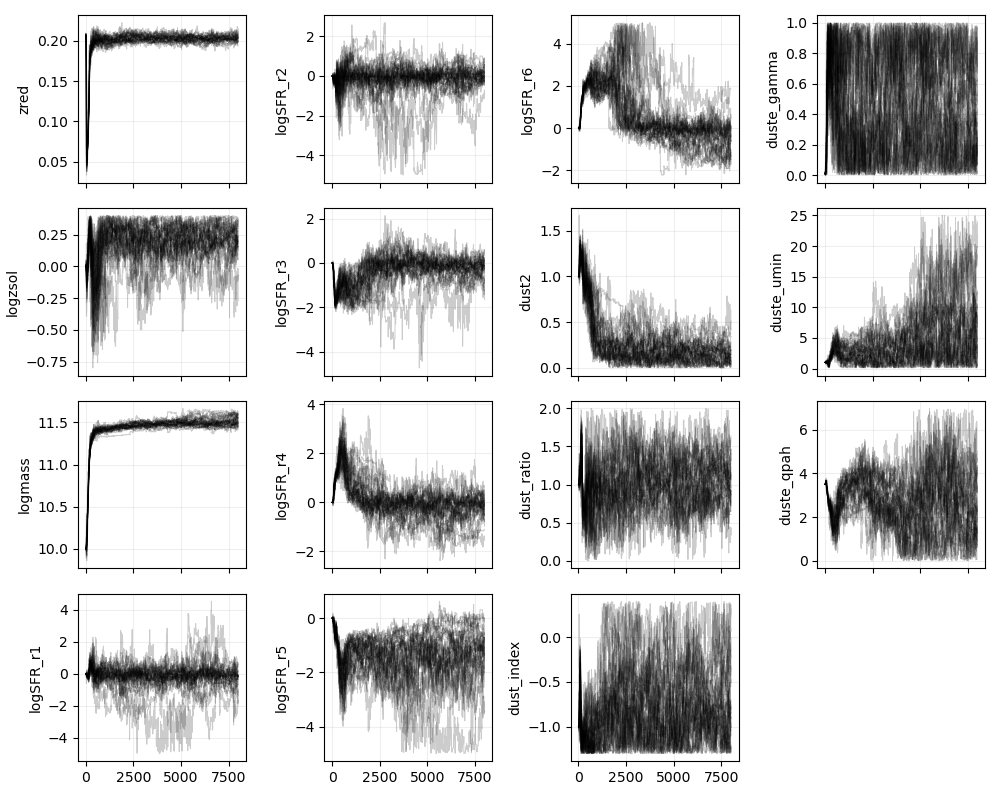

In [17]:
plt.close()
pm_lib.plot_chain(pmcmc.full_samples, ylabels=pmcmc.theta.ylabels, alpha=0.2)

You can still interact with `emcee` sampler directly via `pmcmc.sampler`, for example calculating the full autocorrelation time.  
Check autocorrelation time with `emcee` built-in functions and play around with different discard & thin:

In [18]:
pmcmc.sampler.get_autocorr_time(discard=2000, thin=10, quiet=True)  # use quiet=True to avoid this function giving error

The chain is shorter than 50 times the integrated autocorrelation time for 15 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 12;
tau: [43.04435364 45.75789073 56.91187894 42.51133307 40.84063443 39.94979959
 44.58344863 52.65868545 62.64303061 46.69378589 39.54630115 45.96391336
 40.46301237 51.74527985 49.45965657]


array([430.44353644, 457.57890728, 569.11878941, 425.1133307 ,
       408.40634425, 399.49799594, 445.83448628, 526.58685445,
       626.43030605, 466.93785889, 395.46301151, 459.63913356,
       404.6301237 , 517.45279854, 494.59656574])

To get the results easily in 1 single step, use `pmcmc.get_results(discard, thin)`.  
It returns a dictionary containing most of the useful information.  
These results used discard and thin (if not given in this function, it uses the global that you set during construction of `pmcmc`).

In [20]:
mcmc_results = pmcmc.get_results(discard=4000, thin=10)

Plot the corner plot with the `flat_samples` in the results:  
(this function takes several keyword dictionaries that are supported by `corner.py`)

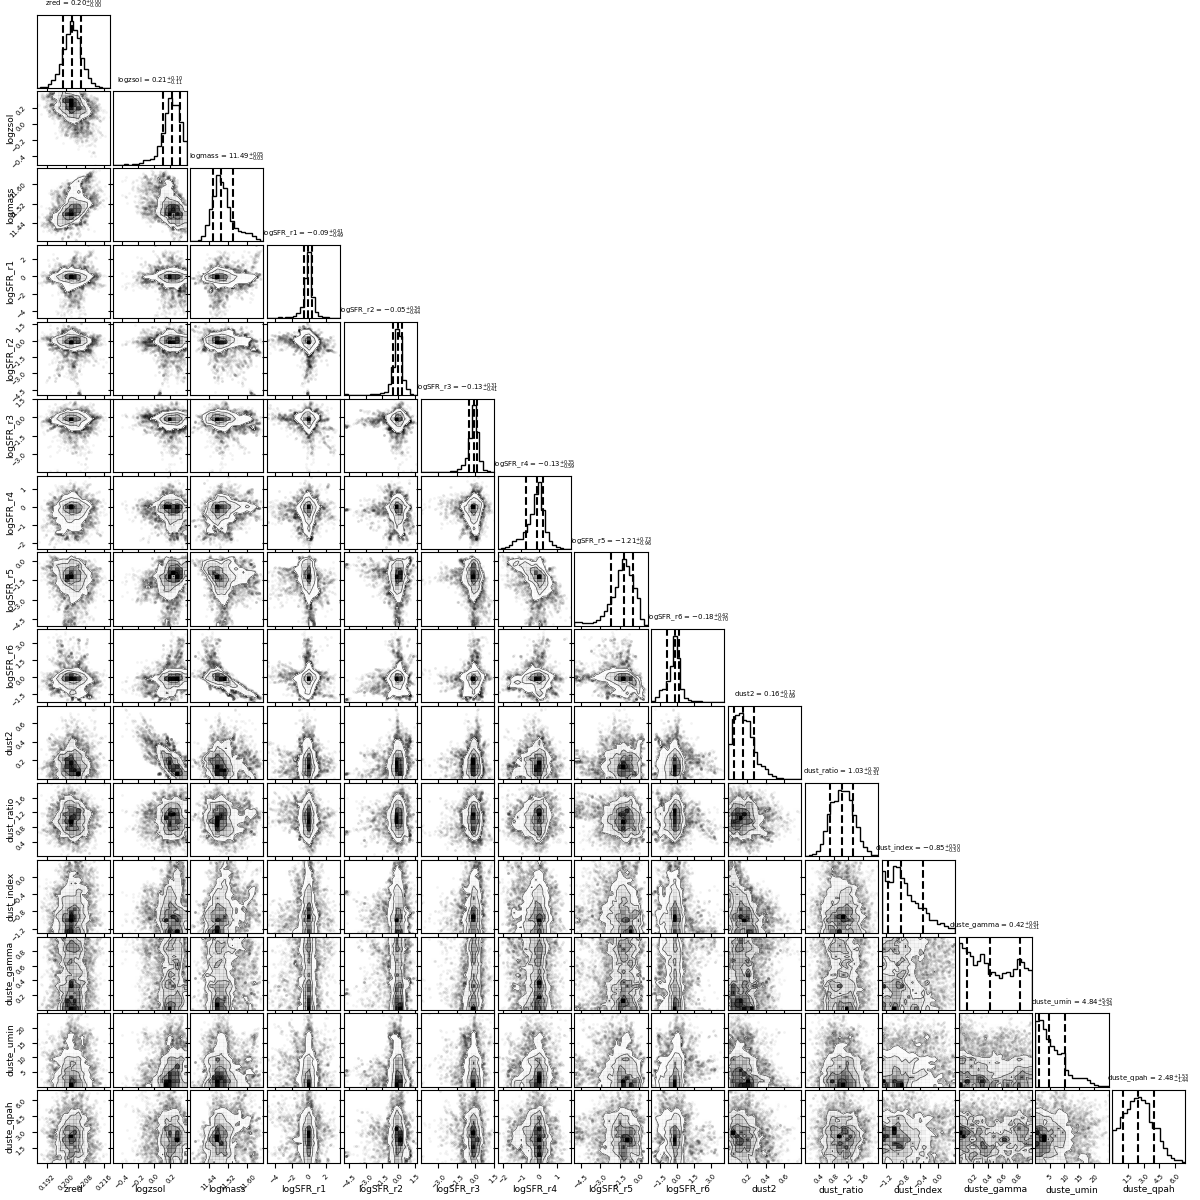

In [21]:
plt.close()
pm_lib.plot_corner(mcmc_results['flat_samples'], 
               ylabels=pmcmc.theta.ylabels, 
               data_kwargs={'alpha': 0.05}, 
               contour_kwargs={'alpha': 0.7, 'linewidths': 0.5},
               figsize=(12, 12))

Display results nicely with `pm_lib.display_fits`.  
mcmc_results['theta_percentiles'] contains a (3, ntheta) array for each parameters in 16, 50, 84 percentile.  
To make sure which parameters they are, you can always check `pmcmc.theta.ylabels` for their names.  

In [22]:
pm_lib.display_fits(mcmc_results['theta_percentiles'], ylabels=pmcmc.theta.ylabels)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

We can now plot the model spectra comparing with the input data, along with fitted Star Formation History.  
But in order to show the credible levels for SFH, we need to calculate them from the flat_samples, using `pm_lib.continuity_sfh_percentiles_steps` function:  

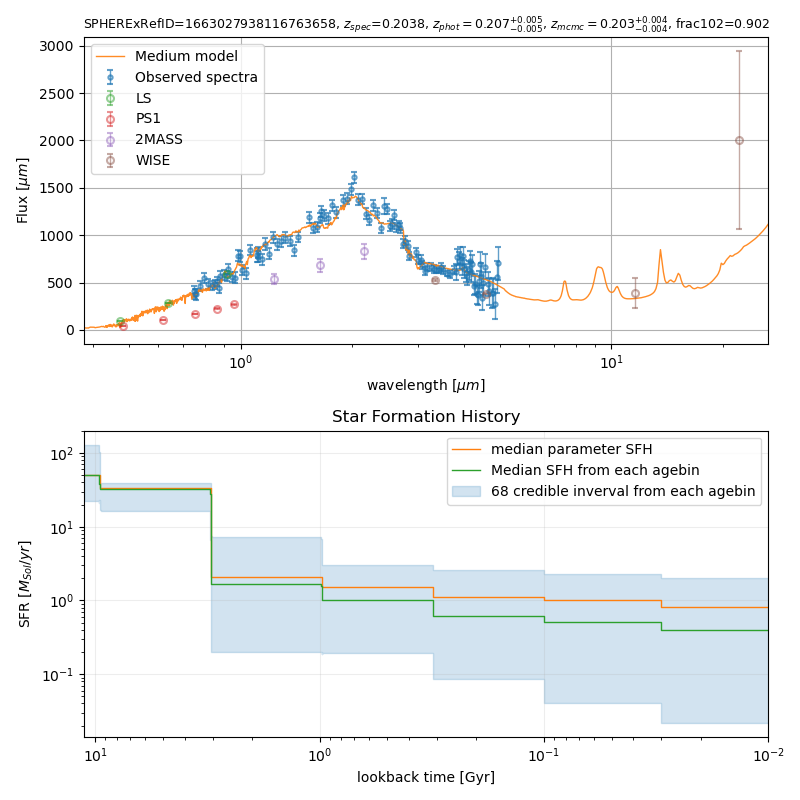

In [23]:
qs_agelims, qs_agebins_all_sfrs = pm_lib.continuity_sfh_percentiles_steps(
    mcmc_results['flat_samples'],
    theta=pmcmc.theta   # this is for the function to know which parameters to look for; you can also manually give it the index numbers
)

theta_percentiles = mcmc_results['theta_percentiles']
mcmc_med_redshift = theta_percentiles[1, pmcmc.theta.zred_idx]  # theta_percentiles[1] is the 50 percentile


plt.close()
pm_lib.plot_sed_sfh(
        lamb_obs,
        spec,
        err,
        lamb_model=mcmc_results['med_lbs'] * (1+mcmc_med_redshift), # 'med_lbs' gives you wavelength in Rest-Frame
        spec_model=mcmc_results['med_spectra'],
        agelims_model=mcmc_results['med_agebins'],  # optional; if not provided this function only draws the spectra
        sfrsteps_model=mcmc_results['med_sfrs'],    # optional; if not provided this function only draws the spectra
        qs_agelims=qs_agelims,              # optional
        qs_sfrsteps=qs_agebins_all_sfrs,    # optional
        external_phots=external_phots,      # optional
        title_kwargs={                      # optional
        'spherex_id': sid,
        'zspec': zspec,
        'zphot': zphot,
        'zphot_u68': zphot_u68,
        'zphot_l68': zphot_l68,
        'zmcmc_med': theta_percentiles[1, pmcmc.theta.zred_idx],
        'zmcmc_16': theta_percentiles[0, pmcmc.theta.zred_idx],
        'zmcmc_84': theta_percentiles[2, pmcmc.theta.zred_idx],
        'frac102': frac102,
        'fontsize': 9,
        }        
    )

To save the results to a `.h5` file, use `pm_lib.save_h5_results()`  
Any metadata that user wishes to be saved as well can be added via `metadata` as dictionary entries

In [28]:
pm_lib.save_h5_results(mcmc_results,
                    output_filename=f'mcmc_results_report_{sid}.h5',
                    metadata={
                            'ylabels': mcmc_results['ylabels'],
                            'SPHERExRefID': sid,
                            'zspec': zspec,
                            'zphot': zphot,
                            'zphot_u68': zphot_u68,
                            'zphot_l68': zphot_l68,
                            'zphot_std': zphot_std,
                            'nwalkers': pmcmc.nwalkers,
                            'jitter': pmcmc.jitter,
                            'nsteps': pmcmc.nsteps,
                            'discard': pmcmc.discard,
                            'thin': pmcmc.thin,
                            'zprior': pmcmc.zprior,
                            'parallel': pmcmc.parallel
                        }
                    )

You always read the saved information with `pm_lib.read_h5_results()`  
This will read it back as the same format as mcmc_results dictionary, except with some added metadata of the run in 'attributes'

In [29]:
read_results = pm_lib.read_h5_results(f'mcmc_results_report_{sid}.h5')
read_results['attributes']

{'SPHERExRefID': np.int64(1663027938116763658),
 'discard': np.int64(2000),
 'jitter': np.float64(0.0001),
 'nsteps': np.int64(8000),
 'nwalkers': np.int64(32),
 'parallel': np.False_,
 'thin': np.int64(10),
 'ylabels': array(['zred', 'logzsol', 'logmass', 'logSFR_r1', 'logSFR_r2',
        'logSFR_r3', 'logSFR_r4', 'logSFR_r5', 'logSFR_r6', 'dust2',
        'dust_ratio', 'dust_index', 'duste_gamma', 'duste_umin',
        'duste_qpah'], dtype=object),
 'zphot': np.float64(0.20687519581712713),
 'zphot_l68': np.float64(0.2017900049686432),
 'zphot_std': np.float64(0.004893631671922704),
 'zphot_u68': np.float64(0.21143999695777893),
 'zprior': np.True_,
 'zspec': np.float64(0.20378386554457492)}

In [30]:
list(read_results.keys())

['autocorr',
 'flat_mfracs',
 'flat_samples',
 'med_agebins',
 'med_flux_conv',
 'med_lbs',
 'med_massbins',
 'med_mfrac',
 'med_myparam',
 'med_sfrs',
 'med_spectra',
 'mfracs_percentiles',
 'theta_percentiles',
 'ylabels',
 'attributes']